# Hands-on Session 4 - Hybrid Quantum-Classical Neural Networks for Earth Observation

## Imports

In [101]:
import matplotlib.pyplot as plt
import numpy as onp
import pennylane.numpy as np
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import minmax_scale

import pennylane as qml

from scipy.linalg import logm
from time import perf_counter
import jax
jax.config.update("jax_enable_x64", True)

In [102]:
# Parameters

sample_size_per_class = 50
test_size = 0.8
n_components = 2
SEED = 42
np.random.seed(SEED)
onp.random.seed(SEED)

# Hybrid Quantum-classical Neural Networks

## 1. Introduction

## 2. Dataset Definition

We now start with a quantum kernel classification workflow for cloud detection using `Pennylane`.

For this example, we will work on cloud detection. We will consider a Landsat-8 image taken from the `38-Cloud` dataset [1]. You can find it in `data/`.

[1] S. Mohajerani, T. A. Krammer and P. Saeedi, "A Cloud Detection Algorithm for Remote Sensing Images Using Fully Convolutional Neural Networks," 2018 IEEE 20th International Workshop on Multimedia Signal Processing (MMSP), Vancouver, BC, 2018, pp. 1-5. doi: 10.1109/MMSP.2018.8547095 URL: http://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=8547095&isnumber=8547039


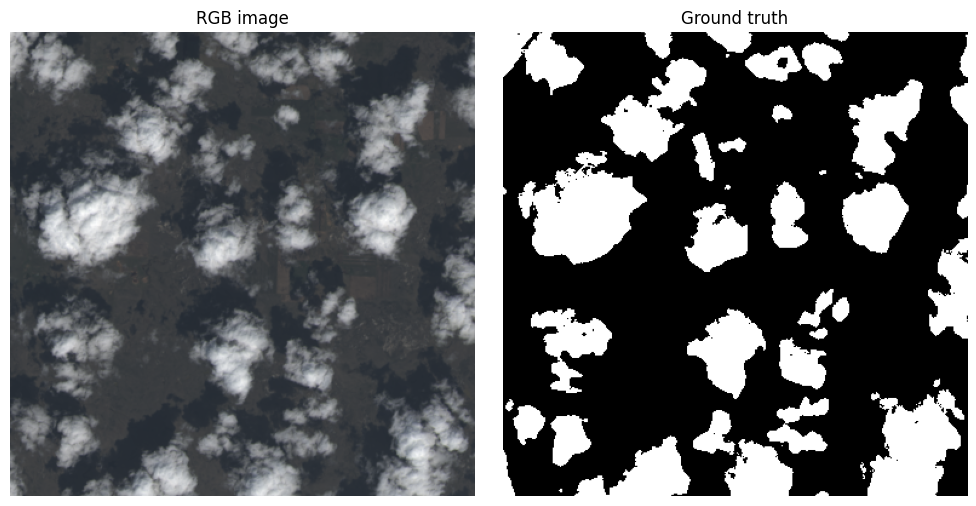

In [103]:
red_channel = plt.imread("data/red_patch_28_2_by_7_LC08_L1TP_032029_20160420_20170223_01_T1.TIF")
green_channel = plt.imread("data/green_patch_28_2_by_7_LC08_L1TP_032029_20160420_20170223_01_T1.TIF")
blue_channel = plt.imread("data/blue_patch_28_2_by_7_LC08_L1TP_032029_20160420_20170223_01_T1.TIF")
nir_channel = plt.imread("data/nir_patch_28_2_by_7_LC08_L1TP_032029_20160420_20170223_01_T1.TIF")

red_channel = red_channel / np.max(red_channel)
green_channel = green_channel / np.max(green_channel)
blue_channel = blue_channel / np.max(blue_channel)
nir_channel = nir_channel / np.max(nir_channel)

rgb_image = np.stack((red_channel, green_channel, blue_channel), axis=-1)

gt_patch = plt.imread("data/gt_patch_28_2_by_7_LC08_L1TP_032029_20160420_20170223_01_T1.tif")
gt_patch = gt_patch / np.max(gt_patch) * 2 - 1  # Scales to {-1, 1}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(rgb_image)
axes[0].set_title("RGB image")
axes[0].axis("off")

axes[1].imshow(gt_patch, cmap="gray")
axes[1].set_title("Ground truth")
axes[1].axis("off")

plt.tight_layout()
plt.show() 


We chose a sample of balanced labeled pixels for training and testing, defined from `sample_size_per_class`.

In [104]:
# Define full dataset
x_full = np.stack((red_channel.flatten(), green_channel.flatten(), blue_channel.flatten(), nir_channel.flatten()), axis=-1)
y = gt_patch.flatten()

# Extract subset
pos_indices = np.where(y == 1)[0]
neg_indices = np.where(y == -1)[0]
rng = np.random.default_rng(seed=SEED)
pos_sample_indices = rng.choice(pos_indices, size=sample_size_per_class, replace=False)
neg_sample_indices = rng.choice(neg_indices, size=sample_size_per_class, replace=False)
sample_indices = np.concatenate((pos_sample_indices, neg_sample_indices))
x_sample = x_full[sample_indices]
y_sample = y[sample_indices]

In [105]:
pca = PCA(n_components=n_components)
x = pca.fit_transform(x_sample)
x = minmax_scale(x, (0,onp.pi))
x_train, x_test, y_train, y_test = train_test_split(x, y_sample, test_size=test_size)

We have measurements for four wavelengths: blue (450-515 nm), green (520-600 nm), red (630-680 nm) and NIR (845-885 nm) with labels '0' (no-clouds) and '1' (clouds).

We need to scale the features to $[0, 2\pi]$ so that we can encode them as rotation gates.
We also create the train-test splits.

Let's plot it now:

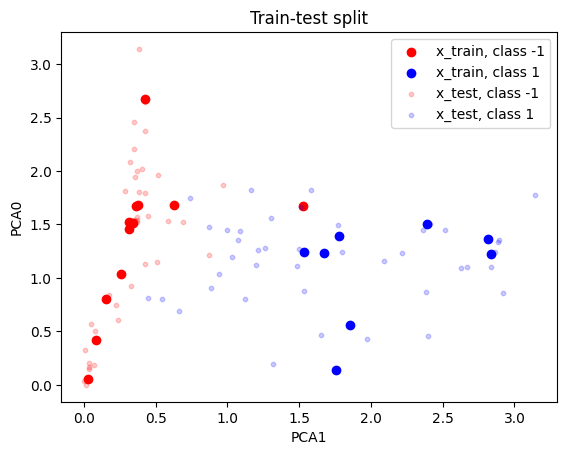

In [106]:
plt.scatter(*(x_train[y_train==-1].T), color='red', marker='o', label='x_train, class -1')
plt.scatter(*(x_train[y_train==1].T), color='blue', marker='o', label='x_train, class 1')
plt.scatter(*(x_test[y_test==-1].T), color='red', marker='o', s=10, alpha=0.2, label='x_test, class -1')
plt.scatter(*(x_test[y_test==1].T), color='blue', marker='o', s=10, alpha=0.2, label='x_test, class 1')
plt.legend()
plt.ylabel('PCA0')
plt.xlabel('PCA1')
plt.title('Train-test split')
plt.show()

# Parameterized quantum circuits

A **Parametrized Quantum Circuit** (PQC) is a quantum circuit that contains **tunable parameters** typically represented as rotation angles or coupling strengths whose values control the quantum operations performed on qubits.

### Core Concept

```
Classical Parameters (θ) → Quantum Circuit → Quantum State → Measurement → Classical Output
```

Unlike fixed quantum circuits (such as the kernels in the previous session), the behavior of PQCs changes based on the parameter values `θ`, making them trainable.

### Structure of a PQC

A typical PQC consists of:
1. **Input Encoding Layer**: Maps classical data `x` into quantum amplitudes (e.g., using `RX(x)`, `RZ(x)` gates)
2. **Parametrized Layer**: Contains tunable rotation gates (e.g., `RY(θ₁)`, `RZ(θ₂)`)
3. **Entangling Layer**: Creates quantum correlations between qubits (e.g., CNOT, CZ gates)
4. **Measurement**: Observes qubit states to get classical outcomes

### How PQCs are Trained: Quantum-Classical Hybrid Loop

Training a PQC is fundamentally different from classical neural networks:

| Step | Description |
|------|-------------|
| **1. Forward Pass** | Feed classical data `x` and parameters `θ` into the PQC; execute on quantum hardware/simulator; obtain measurement outcome |
| **2. Loss Calculation** | Compute classical loss `L(θ)` based on the quantum measurement and target labels |
| **3. Gradient Estimation** | Use the **parameter-shift rule** to compute ∂L/∂θ by running the circuit multiple times with perturbed parameters |
| **4. Parameter Update** | Update `θ` using classical optimizers (SGD, Adam, etc.) |

#### The Parameter-Shift Rule

For a rotation gate `R(θ)` with generator `G`, the gradient is:

```
∂f/∂θ = [f(θ + π/2) - f(θ - π/2)] / 2
```

This requires **2 circuit evaluations per parameter** (one for each shift), making quantum gradients more expensive than classical ones.
Since we will be simulating the quantum circuits, here we can run standard backpropagation, so parameter-shift is not needed. The gradients are not accessible directly in real circuits though.

### Visual Workflow

```
 Classical Data (x)     Parameters (θ)
        │                      │
        ▼                      ▼
   ┌───────────────┐    ┌───────────────┐
   │  Encoder      │    │  Parametrized │
   │  (x ↦ |ψ(x)⟩) │    │  Gates (U(θ)) │
   └───────┬───────┘    └───────┬───────┘
           │                    │
           └──────────┬─────────┘
                      ▼
            ┌──────────────────────────┐
            │     Quantum Circuit      │
            │   |ψ(x, θ)⟩ = U(θ)|ψ(x)⟩ │
            └─────────┬────────────────┘
                      ▼
            ┌───────────────────┐
            │    Measurement    │
            │   Expectation ⟨O⟩ │
            └─────────┬─────────┘
                      ▼
            ┌───────────────────┐
            │   Classical Loss  │
            │   L(θ)            │
            └─────────┬─────────┘
                      ▼
            ┌───────────────────┐
            │  Gradient (∂L/∂θ) │
            │  via parameter-   │
            │  shift rule or    |
            |  backpropagation  │
            └─────────┬─────────┘
                      ▼
            ┌───────────────────┐
            │  Optimizer Update │
            │  θ ← θ - α·∂L/∂θ  │
            └───────────────────┘

In [107]:
# Optional: try PCA if features > 2
def ensure_2_features(X_train, X_test):
    X_train = onp.array(X_train)
    X_test = onp.array(X_test)
    if X_train.ndim == 1:
        X_train = X_train.reshape(-1, 1)
    if X_test.ndim == 1:
        X_test = X_test.reshape(-1, 1)

    n_features = X_train.shape[1]
    if n_features == 2:
        return X_train, X_test

    # Try PCA if sklearn available
    try:
        pca = PCA(n_components=2)
        X_all = onp.vstack([X_train, X_test])
        X_all2 = pca.fit_transform(X_all)
        X_train2 = X_all2[: len(X_train)]
        X_test2 = X_all2[len(X_train):]
        return X_train2, X_test2
    except Exception:
        if n_features >= 2:
            return X_train[:, :2], X_test[:, :2]
        else:
            # If only 1 feature, pad with zeros
            X_train2 = onp.hstack([X_train, onp.zeros((X_train.shape[0], 1))])
            X_test2 = onp.hstack([X_test, onp.zeros((X_test.shape[0], 1))])
            return X_train2, X_test2

# Map expectation value in [-1,1] to probability in [0,1]
def expval_to_prob(e):
    return (e + 1.0) / 2.0

In [108]:
# ---------------------------------------------------------
#  Device
# ---------------------------------------------------------
dev = qml.device("default.qubit", wires=2)

# ---------------------------------------------------------
#  Variational block (one layer of the quantum neural network)
# ---------------------------------------------------------
def variational_layer(params):
    # params shape for one layer: (4,) -> [rx0, ry0, rx1, ry1]
    qml.RX(params[0], wires=0)
    qml.RY(params[1], wires=0)
    qml.RX(params[2], wires=1)
    qml.RY(params[3], wires=1)
    # entangle
    qml.CNOT(wires=[0, 1])

# ---------------------------------------------------------
#  QNode: 2-qubit quantum neural network classifier
# ---------------------------------------------------------
@qml.qnode(dev, interface="autograd", diff_method="backprop")
def qnn(params, x):
    # x: array of length 2 (two features)
    # params: shape (n_layers, 4)
    qml.templates.AngleEmbedding(x, wires=[0, 1])
    for layer_params in params:
        variational_layer(layer_params)
    # Readout on qubit 0
    return qml.expval(qml.PauliZ(0))

In [109]:
# ---------------------------------------------------------
#  Loss
# ---------------------------------------------------------
def binary_cross_entropy(params, X, Y):
    # X: shape (n_samples, 2)
    # Y: shape (n_samples,) with 0/1
    losses = 0.0
    for x, y in zip(X, Y):
        e = qnn(params, x)
        p = expval_to_prob(e)
        # Clip for numerical stability
        p = np.clip(p, 1e-6, 1 - 1e-6)
        losses = losses - (y * np.log(p) + (1 - y) * np.log(1 - p))
    return losses / len(X)

In [110]:
# ---------------------------------------------------------
#  Helpers
# ---------------------------------------------------------
def predict(params, X):
    preds = []
    for x in X:
        e = qnn(params, x)
        p = expval_to_prob(e)
        preds.append(1 if p >= 0.5 else 0)
    return onp.array(preds)

def accuracy(params, X, Y):
    preds = predict(params, X)
    return onp.mean(preds == Y)

# ---------------------------------------------------------
#  Draw circuit using Matplotlib
# ---------------------------------------------------------
def draw_qnn_circuit_mpl(params, x):
    """
    Return a matplotlib Figure rendering the QNN circuit.
    """
    fig = qml.draw_mpl(qnn)(params, x)
    return fig

# ---------------------------------------------------------
#  Training routine
# ---------------------------------------------------------
def train_qnn(x_train, x_test, y_train, y_test,
              n_layers=2, epochs=100, lr=0.05, verbose=True):
    # Prepare data
    X_train, X_test = ensure_2_features(x_train, x_test)
    Y_train = onp.array(y_train).astype(int)
    Y_test = onp.array(y_test).astype(int)

    # If labels are in {-1, 1}, convert them
    if set(onp.unique(Y_train)) <= {-1, 1}:
        Y_train = ((Y_train + 1) // 2).astype(int)
        Y_test = ((Y_test + 1) // 2).astype(int)

    # Convert to pennylane numpy arrays (for gradients)
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    Y_train = np.array(Y_train)
    Y_test = np.array(Y_test)

    # Initialize parameters: shape (n_layers, 4)
    params = np.random.randn(n_layers, 4) * 0.1
    params = np.array(params, requires_grad=True)

    # Optimizer (PennyLane's optimizer)
    opt = qml.optimize.AdamOptimizer(stepsize=lr)

    # Training loop (full-batch)
    for epoch in range(epochs):
        params = opt.step(lambda v: binary_cross_entropy(v, X_train, Y_train), params)
        if verbose and (epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1):
            tr_loss = binary_cross_entropy(params, X_train, Y_train)
            tr_acc = accuracy(params, X_train, Y_train)
            te_acc = accuracy(params, X_test, Y_test)
            print(f"Epoch {epoch+1:3d}/{epochs}  Loss {tr_loss:.4f}  Train acc {tr_acc:.3f}  Test acc {te_acc:.3f}")

    final_train_acc = accuracy(params, X_train, Y_train)
    final_test_acc = accuracy(params, X_test, Y_test)

    if verbose:
        print("Training finished.")
        print(f"Final train accuracy: {final_train_acc:.3f}")
        print(f"Final test  accuracy: {final_test_acc:.3f}")

    return params, (final_train_acc, final_test_acc)

(<Figure size 1300x300 with 1 Axes>, <Axes: >)

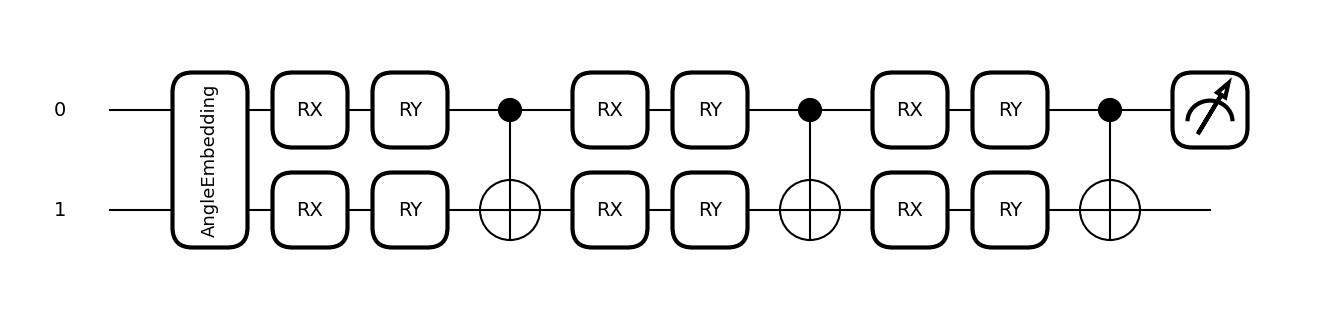

In [111]:
params = np.random.randn(3, 4)  # 2 layers, 4 parameters each
x = np.array([0.1, 0.2])        # example input features
draw_qnn_circuit_mpl(params=params, x=x)

In [112]:
params, (train_acc, test_acc) = train_qnn(x_train, x_test, y_train, y_test,n_layers=3, epochs=200, lr=0.02)

Epoch   1/200  Loss 2.7833  Train acc 0.100  Test acc 0.300
Epoch  21/200  Loss 1.0581  Train acc 0.050  Test acc 0.100
Epoch  41/200  Loss 0.4805  Train acc 0.950  Test acc 0.713
Epoch  61/200  Loss 0.2794  Train acc 1.000  Test acc 0.725
Epoch  81/200  Loss 0.2144  Train acc 0.950  Test acc 0.762
Epoch 101/200  Loss 0.1960  Train acc 0.950  Test acc 0.775
Epoch 121/200  Loss 0.1912  Train acc 0.950  Test acc 0.787
Epoch 141/200  Loss 0.1881  Train acc 0.950  Test acc 0.787
Epoch 161/200  Loss 0.1855  Train acc 0.950  Test acc 0.787
Epoch 181/200  Loss 0.1836  Train acc 0.950  Test acc 0.787
Epoch 200/200  Loss 0.1823  Train acc 0.950  Test acc 0.787
Training finished.
Final train accuracy: 0.950
Final test  accuracy: 0.787


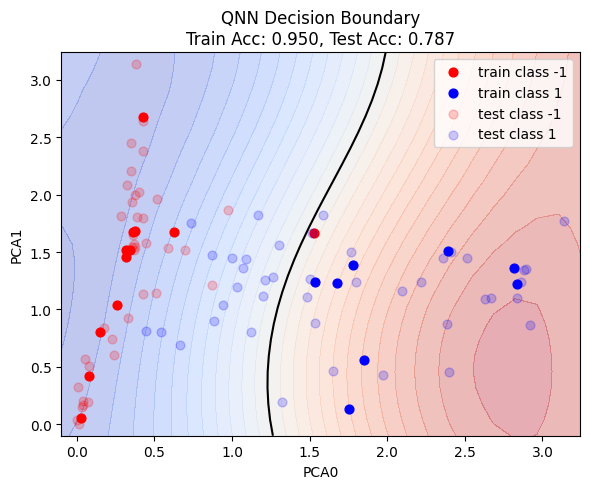

In [ ]:
# Plot decision boundary for QNN with the style you specified
def plot_qnn_decision_boundary(params, x_train, y_train, x_test, y_test, 
                               train_acc=None, test_acc=None, 
                               save_path=None, title="QNN Decision Boundary"):
    """
    Plot QNN decision boundary matching the quantum kernel style.
    """
    # Prepare data
    x_train = onp.array(x_train)
    x_test = onp.array(x_test)
    y_train = onp.array(y_train)
    y_test = onp.array(y_test)
    
    # Define grid boundaries based on all data
    x_all = onp.vstack([x_train, x_test])
    x0_min, x0_max = x_all[:, 0].min() - 0.1, x_all[:, 0].max() + 0.1
    x1_min, x1_max = x_all[:, 1].min() - 0.1, x_all[:, 1].max() + 0.1
    
    # Create grid
    grid_size = 25  # Same as your quantum kernel example
    xx, yy = onp.meshgrid(
        onp.linspace(x0_min, x0_max, grid_size),
        onp.linspace(x1_min, x1_max, grid_size),
    )
    grid_points = onp.c_[xx.ravel(), yy.ravel()]
    
    # Compute scores for QNN (expectation values - similar to decision function)
    scores = []
    for point in grid_points:
        e = qnn(params, point)  # Your QNN function
        scores.append(e)  # Use raw expectation value as score
    scores = onp.array(scores).reshape(xx.shape)
    
    # Create plot with same style as quantum kernel examples
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Decision regions with coolwarm colormap
    ax.contourf(xx, yy, scores, levels=30, cmap="coolwarm", alpha=0.35)
    
    # Decision boundary (zero contour line)
    ax.contour(xx, yy, scores, levels=[0], colors="k", linewidths=1.5)
    
    # Training points
    ax.scatter(
        x_train[y_train == -1, 0], x_train[y_train == -1, 1],
        color="red", marker="o", s=40, label="train class -1"
    )
    ax.scatter(
        x_train[y_train == 1, 0], x_train[y_train == 1, 1],
        color="blue", marker="o", s=40, label="train class 1"
    )
    
    # Test points
    ax.scatter(
        x_test[y_test == -1, 0], x_test[y_test == -1, 1],
        color="red", marker="o", s=40, alpha=0.2, label="test class -1"
    )
    ax.scatter(
        x_test[y_test == 1, 0], x_test[y_test == 1, 1],
        color="blue", marker="o", s=40, alpha=0.2, label="test class 1"
    )
    
    # Add title with accuracy info
    title_text = title
    if train_acc is not None and test_acc is not None:
        title_text += f"\nTrain Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}"
    ax.set_title(title_text)
    
    ax.set_xlabel("PCA0")
    ax.set_ylabel("PCA1")
    ax.legend(loc="best")
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

# Plot the QNN decision boundary
plot_qnn_decision_boundary(
    params, x_train, y_train, x_test, y_test,
    train_acc=train_acc, test_acc=test_acc
)